In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [10]:
iris = load_iris()

X = iris.data
y = iris.target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
neuron_counts = [5, 20, 50]

results = []


for neurons in neuron_counts:

    print("\nTraining ANN with", neurons, "hidden neurons")

    # ANN Architecture
    model = keras.Sequential([

        # Input Layer
        keras.layers.Input(shape=(4,)),

        # Hidden Layer
        keras.layers.Dense(
            neurons,
            activation="relu"
        ),
         # Output Layer
        keras.layers.Dense(
            3,
            activation="softmax"
        )
    ])



Training ANN with 5 hidden neurons

Training ANN with 20 hidden neurons

Training ANN with 50 hidden neurons


In [17]:
 model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

In [15]:
 history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )


In [18]:
 y_probability = model.predict(
        X_test,
        verbose=0
    )

 y_pred = np.argmax(
        y_probability,
        axis=1
    )

In [21]:
 accuracy = accuracy_score(
        y_test,
        y_pred
    )

 precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

 recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

 f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

 # Store results
 results.append([
        neurons,
        accuracy,
        precision,
        recall,
        f1
    ])

In [22]:
print("\n")
print("=" * 65)

print(
    f"{'Hidden Neurons':<18}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1-Score':<12}"
)

print("=" * 65)


for result in results:

    print(
        f"{result[0]:<18}"
        f"{result[1]:<12.4f}"
        f"{result[2]:<12.4f}"
        f"{result[3]:<12.4f}"
        f"{result[4]:<12.4f}"
    )





Hidden Neurons    Accuracy    Precision   Recall      F1-Score    
50                0.9333      0.9333      0.9333      0.9333      


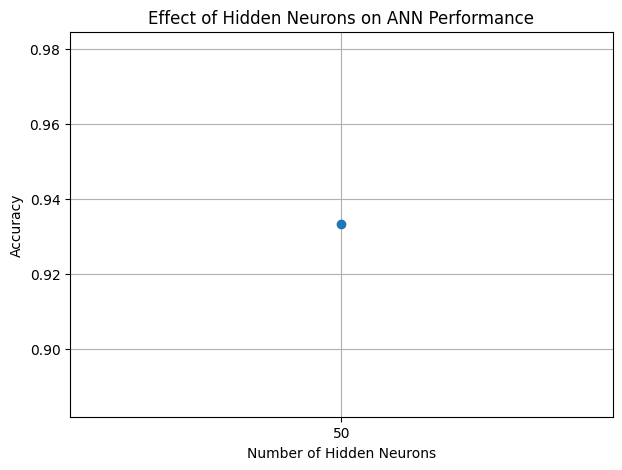

In [23]:
neurons = [r[0] for r in results]

accuracy = [r[1] for r in results]


plt.figure(figsize=(7, 5))

plt.plot(
    neurons,
    accuracy,
    marker="o"
)

plt.xlabel("Number of Hidden Neurons")

plt.ylabel("Accuracy")

plt.title(
    "Effect of Hidden Neurons on ANN Performance"
)

plt.xticks(neurons)

plt.grid(True)
plt.show()
